In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("cleaned_football_data.csv")

print(df.head())
print(df.info())
print(df.describe())

         date    home_team   away_team  home_goals  away_goals result  \
0  2010-08-14  Aston Villa    West Ham           3           0      H   
1  2010-08-14    Blackburn     Everton           1           0      H   
2  2010-08-14       Bolton      Fulham           0           0      D   
3  2010-08-14      Chelsea   West Brom           6           0      H   
4  2010-08-14   Sunderland  Birmingham           2           2      D   

   home_shots  away_shots  home_shots_target  away_shots_target   season  \
0          23          12                 11                  2  2010_11   
1           7          17                  2                 12  2010_11   
2          13          12                  9                  7  2010_11   
3          18          10                 13                  4  2010_11   
4           6          13                  2                  7  2010_11   

  League  
0    EPL  
1    EPL  
2     EP  
3    EPL  
4    EPL  
<class 'pandas.core.frame.DataFrame'>


In [3]:
df = df.drop("date", axis=1)
print(df.isnull().sum())
df = df.fillna(0)

home_team            0
away_team            0
home_goals           0
away_goals           0
result               0
home_shots           0
away_shots           0
home_shots_target    0
away_shots_target    0
season               0
League               0
dtype: int64


In [4]:
le_home = LabelEncoder()
le_away = LabelEncoder()
le_league = LabelEncoder()
le_season = LabelEncoder()

df["home_team"] = le_home.fit_transform(df["home_team"])
df["away_team"] = le_away.fit_transform(df["away_team"])
df["League"] = le_league.fit_transform(df["League"])
df["season"] = le_season.fit_transform(df["season"])

In [5]:
result_mapping = {
    'H': 1,   # Home win
    'D': 0,   # Draw
    'A': -1   # Away win
}

df["result"] = df["result"].map(result_mapping)

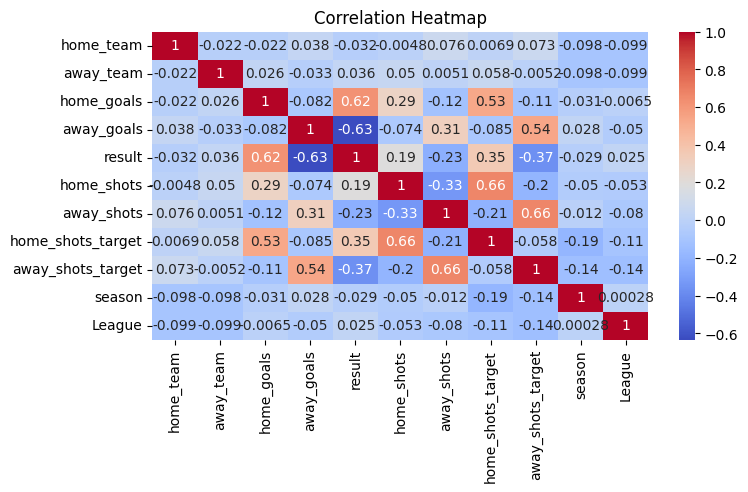

In [6]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

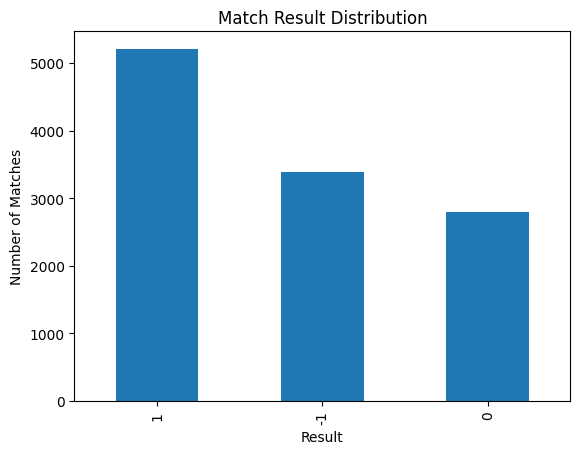

In [7]:
df['result'].value_counts().plot(kind='bar')

plt.title("Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

In [8]:
features = [
    'home_team',
    'away_team',
    'League',
    'season',
    'home_shots',
    'away_shots',
    'home_shots_target',
    'away_shots_target'
]

X = df[features]
y = df["result"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [11]:
pred = model.predict(X_test)
print(pred)

[ 1  1 -1 ...  1  1 -1]


In [12]:
accuracy = accuracy_score(y_test, pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5824561403508772


In [13]:
print("\nClassification Report:\n")
print(classification_report(y_test, pred))


Classification Report:

              precision    recall  f1-score   support

          -1       0.56      0.63      0.60       692
           0       0.39      0.09      0.14       546
           1       0.61      0.81      0.70      1042

    accuracy                           0.58      2280
   macro avg       0.52      0.51      0.48      2280
weighted avg       0.54      0.58      0.53      2280



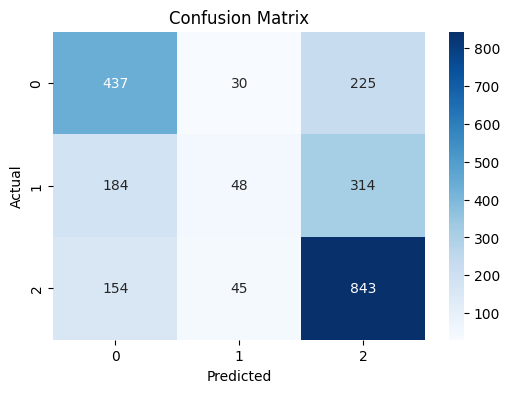

In [14]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

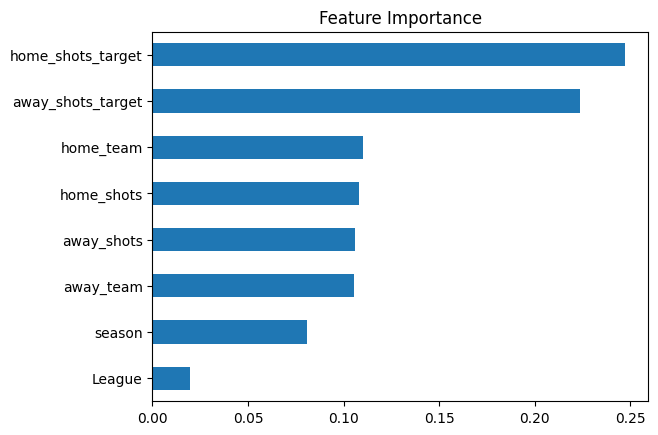

In [15]:
importance = model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

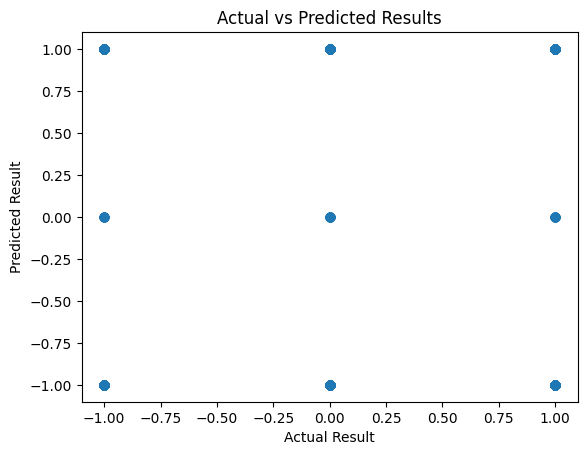

In [16]:
plt.scatter(y_test, pred)

plt.xlabel("Actual Result")
plt.ylabel("Predicted Result")
plt.title("Actual vs Predicted Results")

plt.show()

In [17]:
sample_match = [[
    1,   # home_team encoded value
    2,    # away_team encoded value
    2,    # league
    27,    # season
    12,   # home_shots
    9,    # away_shots
    10,    # home_shots_target
    8     # away_shots_target
]]

prediction = model.predict(sample_match)

print("Predicted Result:", prediction)

Predicted Result: [1]


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


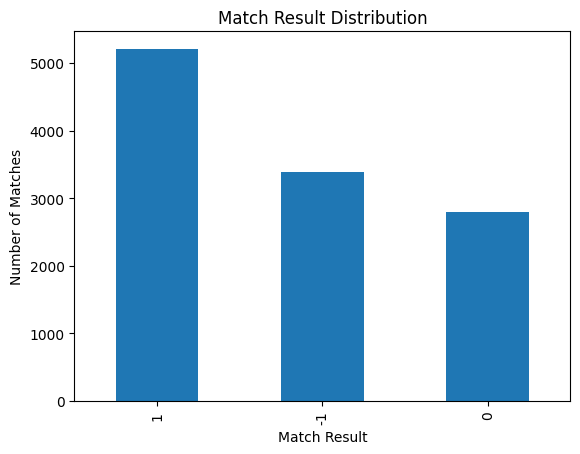

In [7]:
df['result'].value_counts().plot(kind='bar')

plt.title("Match Result Distribution")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")

plt.show()